In [64]:
import pandas as pd
from IPython.core.pylabtools import figsize

train_data = pd.read_csv('Data/final_train.csv', index_col=0)
test_data = pd.read_csv('Data/final_test.csv', index_col=0)

train_x, train_y = train_data.drop('SalePrice', axis=1), train_data['SalePrice']
test_x, test_y = test_data.drop('SalePrice', axis=1), test_data['SalePrice']

train_x

,Foundation_PConc,GarageType_Detchd,GarageType_Attchd,Exterior2nd_VinylSd,MSZoning_RM,Foundation_CBlock,Neighborhood_NAmes,MSZoning_RL,Exterior1st_VinylSd,SaleType_New,...,Bsmt_index,Garage_index,Condition_index,Living_Area,OpenSF,Luxury_index,Comf_idx,FullBath,LotFrontage,YearBuilt
741,True,False,True,False,False,False,False,True,False,False,...,5,6,60.000,35.628359,3.590896,3.875578,9.414997,0.911265,15.604698,1995
865,False,True,False,False,False,True,True,True,False,False,...,3,4,37.500,36.329019,0.000000,0.154925,13.298420,0.911265,26.535234,1949
339,True,False,True,False,False,False,False,True,False,True,...,7,6,30.000,42.542947,3.468843,5.547298,13.581823,1.712883,25.179280,2005
192,False,False,False,False,True,True,False,False,False,False,...,2,0,46.875,37.573278,5.672260,0.000000,17.129117,0.911265,36.667137,1912
203,False,False,True,False,False,True,True,True,False,False,...,4,5,15.000,34.079853,3.168412,4.371354,14.938750,0.911265,31.425563,1964
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1220,True,False,True,False,False,False,True,False,False,False,...,7,6,60.000,34.165046,8.774702,4.159288,9.562460,1.712883,17.186882,1998
1185,False,True,False,True,False,True,True,True,True,False,...,6,4,17.500,33.420319,9.100719,4.004645,14.336896,0.911265,30.469668,1965
1167,True,False,True,True,False,False,False,True,True,False,...,9,5,10.000,36.102675,10.752007,4.472627,14.451533,1.712883,29.826615,2003
517,True,False,True,True,False,False,False,True,True,False,...,4,6,30.000,37.475508,7.784056,1.253723,14.874775,1.712883,31.108063,2004


## Matric Function

In [65]:
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

def metric(y_hat, y_true,features_shape):
    n,p = features_shape
    r2 = r2_score(y_true, y_hat)
    socres = {
        "MAE": mean_absolute_error(y_true, y_hat),
        "MSE": mean_squared_error(y_true, y_hat),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_hat)),
        "R2": r2,
        "Adjusted R2":  1 - (1 - r2) * (n - 1) / (n - p - 1)
    }

    df_score = pd.DataFrame(socres.items(), columns=["Metric","Value"])

    return df_score

def judge(pipe):
    global train_x, train_y, test_x, test_y

    pipe.fit(train_x, train_y)
    train_pred = pipe.predict(train_x)
    test_pred = pipe.predict(test_x)

    train_score = metric(train_y, train_pred, train_x.shape)
    test_score = metric(test_y, test_pred, train_x.shape)

    fig,ax = plt.subplots(1,2, figsize=(10,5))
    ax = ax.flatten()

    sns.barplot(train_score, x='Metric', y='Value', ax=ax[0])
    ax[0].set_title('Train')

    sns.barplot(test_score, x='Metric', y='Value', ax=ax[1])
    ax[1].set_title('Test')

    return train_score, test_score

# Regression Models
In this particular example I will test linear regression, Ridge  and Random Forest Regressor with additional data scaling and feature selection

## Linear Regression Approach

In [66]:
import optuna
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score

def linear_objective(trial, X, y):
    n_features = X.shape[1]
    k = trial.suggest_int("selector__k", 1, n_features)

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('selector', SelectKBest(score_func=f_regression, k=k)),
        ('regressor', LinearRegression())
    ])

    cv = KFold(n_splits=10, shuffle=True, random_state=42)
    score = cross_val_score(
        pipe, X, y,
        cv=cv,
        scoring='neg_mean_squared_error'
    ).mean()

    return score

linear_study = optuna.create_study(direction='maximize')
linear_study.optimize(lambda trial: linear_objective(trial, train_x, train_y), n_trials=25, show_progress_bar=True)

linear_study.best_params

[I 2026-03-25 20:21:20,575] A new study created in memory with name: no-name-04ec5d3e-c3ed-4cbb-b554-b6ac07124b9f


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2026-03-25 20:21:20,839] Trial 0 finished with value: -1560192122.6673403 and parameters: {'selector__k': 21}. Best is trial 0 with value: -1560192122.6673403.
[I 2026-03-25 20:21:21,018] Trial 1 finished with value: -1643644949.6098113 and parameters: {'selector__k': 13}. Best is trial 0 with value: -1560192122.6673403.
[I 2026-03-25 20:21:21,142] Trial 2 finished with value: -1941768782.304433 and parameters: {'selector__k': 3}. Best is trial 0 with value: -1560192122.6673403.
[I 2026-03-25 20:21:21,284] Trial 3 finished with value: -1590140025.2714248 and parameters: {'selector__k': 15}. Best is trial 0 with value: -1560192122.6673403.
[I 2026-03-25 20:21:21,406] Trial 4 finished with value: -1658048700.5473938 and parameters: {'selector__k': 9}. Best is trial 0 with value: -1560192122.6673403.
[I 2026-03-25 20:21:21,517] Trial 5 finished with value: -2401710930.9542704 and parameters: {'selector__k': 1}. Best is trial 0 with value: -1560192122.6673403.
[I 2026-03-25 20:21:21,644

{'selector__k': 24}

,Metric,Value
0,MAE,2.682393e+04
1,MSE,1.792022e+09
2,RMSE,4.233228e+04
3,R2,6.264617e-01
4,Adjusted R2,6.183413e-01


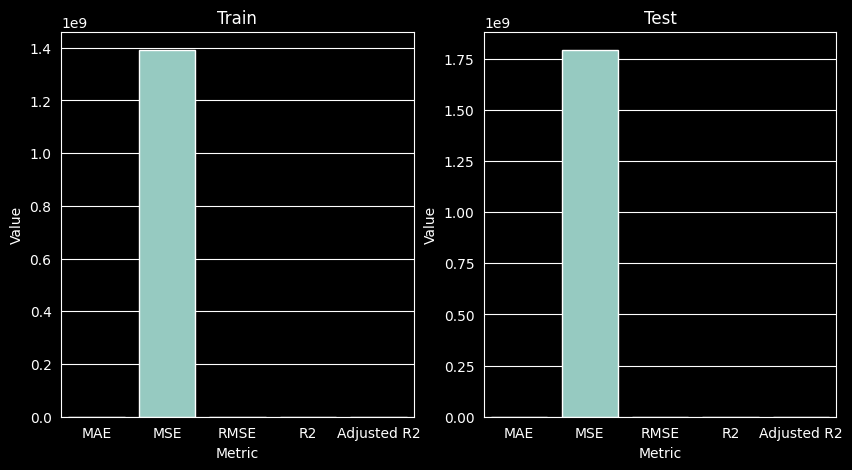

In [67]:
linear_pipline = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(k=10)),
    ('regressor', LinearRegression())
])

linear_pipline.set_params(**linear_study.best_params)

_ , linear_score = judge(linear_pipline)

linear_score

# Ridge

In [68]:
from sklearn.linear_model import Ridge


def ridge_objective(trial, X, y):

    alpha = trial.suggest_float("regressor__alpha", 1e-4, 100.0, log=True)
    tol = trial.suggest_float("regressor__tol", 1e-4, 100.0, log=True)
    solver = trial.suggest_categorical("regressor__solver", ['svd', 'cholesky', 'lsqr'])

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', Ridge(alpha=alpha, tol=tol, solver=solver))
    ])

    cv = KFold(n_splits=10, shuffle=True, random_state=42)

    score = cross_val_score(pipe, X, y, cv=cv, scoring='neg_mean_squared_error').mean()

    return score

ridge_study = optuna.create_study(direction='maximize')
ridge_study.optimize( lambda trial: ridge_objective(trial, train_x, train_y), n_trials=50, show_progress_bar=True)

ridge_study.best_params

[I 2026-03-25 20:21:25,787] A new study created in memory with name: no-name-19d4205b-26e4-4c95-9386-61520b7d92b4


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-03-25 20:21:25,922] Trial 0 finished with value: -1491901541.7510567 and parameters: {'regressor__alpha': 0.004469437259780288, 'regressor__tol': 0.012280423824923599, 'regressor__solver': 'cholesky'}. Best is trial 0 with value: -1491901541.7510567.
[I 2026-03-25 20:21:26,061] Trial 1 finished with value: -1491903655.6693175 and parameters: {'regressor__alpha': 0.0022622313430570463, 'regressor__tol': 0.003106952520639797, 'regressor__solver': 'cholesky'}. Best is trial 0 with value: -1491901541.7510567.
[I 2026-03-25 20:21:26,174] Trial 2 finished with value: -1492190296.263045 and parameters: {'regressor__alpha': 0.6303016909120173, 'regressor__tol': 0.0384839183269165, 'regressor__solver': 'cholesky'}. Best is trial 0 with value: -1491901541.7510567.
[I 2026-03-25 20:21:26,358] Trial 3 finished with value: -1491895266.4429133 and parameters: {'regressor__alpha': 0.017499069013960346, 'regressor__tol': 0.00010220382394139255, 'regressor__solver': 'lsqr'}. Best is trial 3 wit

{'regressor__alpha': 0.1488209642190567,
 'regressor__tol': 0.006227633335811382,
 'regressor__solver': 'cholesky'}

,Metric,Value
0,MAE,2.684763e+04
1,MSE,1.793971e+09
2,RMSE,4.235529e+04
3,R2,6.260957e-01
4,Adjusted R2,6.179674e-01


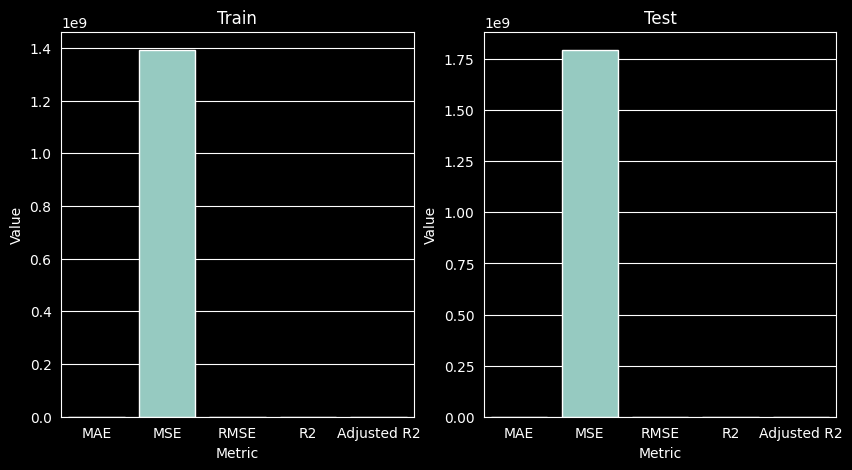

In [69]:
Ridge_pipline = Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', Ridge())
    ])

Ridge_pipline.set_params(**ridge_study.best_params)

_, ridge_score = judge(Ridge_pipline)

ridge_score

## Random Forest
as a solution for highly not linear data

In [70]:
from sklearn.ensemble import RandomForestRegressor

def rf_objective(trial, X, y):
    n_estimators = trial.suggest_int("n_estimators", 50, 800)
    max_depth = trial.suggest_int("max_depth", 2, 45)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 25)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])

    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42,
        n_jobs=-1
    )

    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    score = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring='neg_mean_squared_error',
        n_jobs=-1
    ).mean()

    return score

rf_study = optuna.create_study(direction='maximize')
rf_study.optimize(lambda  trial: rf_objective(trial, train_x, train_y), n_trials=50, show_progress_bar=True)
rf_study.best_params

[I 2026-03-25 20:21:33,956] A new study created in memory with name: no-name-fb7ab864-6457-47fb-b36b-53fc11984a70


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-03-25 20:21:36,915] Trial 0 finished with value: -1140681512.0817118 and parameters: {'n_estimators': 789, 'max_depth': 15, 'min_samples_split': 17, 'min_samples_leaf': 3, 'max_features': None}. Best is trial 0 with value: -1140681512.0817118.
[I 2026-03-25 20:21:37,771] Trial 1 finished with value: -1719353231.8263035 and parameters: {'n_estimators': 366, 'max_depth': 21, 'min_samples_split': 18, 'min_samples_leaf': 16, 'max_features': 'sqrt'}. Best is trial 0 with value: -1140681512.0817118.
[I 2026-03-25 20:21:39,473] Trial 2 finished with value: -1267639976.018436 and parameters: {'n_estimators': 523, 'max_depth': 41, 'min_samples_split': 5, 'min_samples_leaf': 12, 'max_features': None}. Best is trial 0 with value: -1140681512.0817118.
[I 2026-03-25 20:21:40,398] Trial 3 finished with value: -1729075403.1942024 and parameters: {'n_estimators': 425, 'max_depth': 44, 'min_samples_split': 19, 'min_samples_leaf': 17, 'max_features': 'log2'}. Best is trial 0 with value: -1140681

{'n_estimators': 264,
 'max_depth': 28,
 'min_samples_split': 13,
 'min_samples_leaf': 1,
 'max_features': None}

,Metric,Value
0,MAE,2.163119e+04
1,MSE,1.365639e+09
2,RMSE,3.695455e+04
3,R2,7.539107e-01
4,Adjusted R2,7.485609e-01


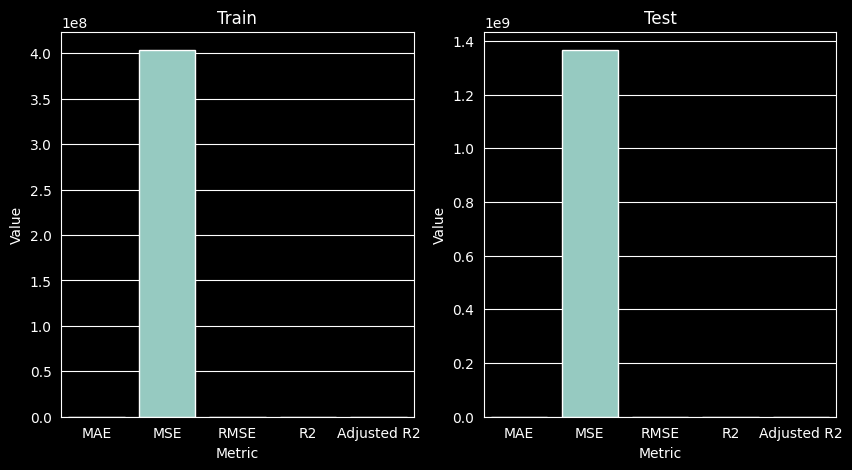

In [72]:
rf_model = RandomForestRegressor()
rf_model.set_params(**rf_study.best_params)

_, rf_score = judge(rf_model)

rf_score

# Results
For reference Dummy regressor.


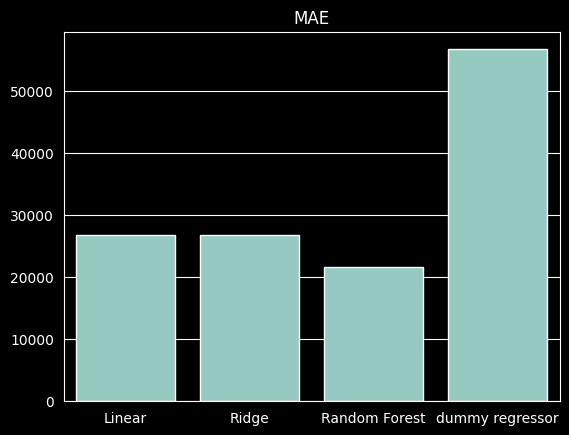

In [88]:
from sklearn.dummy import DummyRegressor
dummy = DummyRegressor(strategy='mean')
dummy.fit(train_x, train_y)
pred_dummy = dummy.predict(test_x)
mae_d = mean_absolute_error(test_y, pred_dummy)

sns.barplot(y = [linear_score.loc[0, 'Value'], ridge_score.loc[0, 'Value'], rf_score.loc[0, 'Value'], mae_d], x = ['Linear', 'Ridge', 'Random Forest', 'dummy regressor'])
plt.title("MAE")
plt.show()

# Comment
As all models performed much better than dummy regressor, the estimated error of 20 k for house price prediction is not satisfying

# Random Forest feature importance
As it is easy to see the data set consist one feature that holds the most information

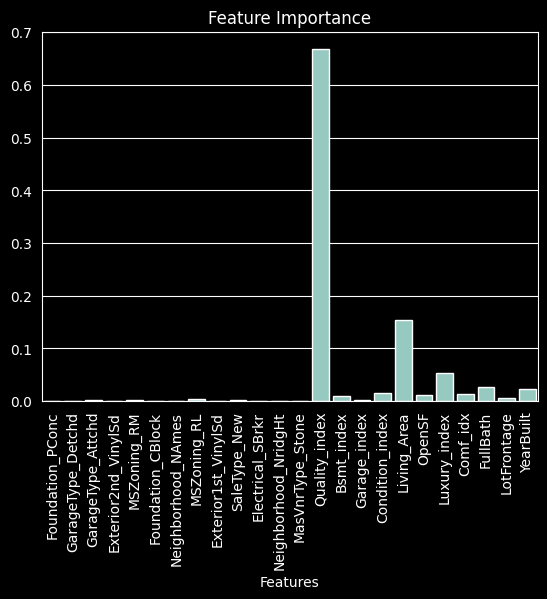

In [101]:
sns.barplot(y = rf_model.feature_importances_, x = train_x.columns)
plt.xlabel('Features')
plt.title("Feature Importance")
plt.xticks(rotation=90)
plt.show()